# Analyse Exploratoire des Données — Projet Alzheimer
## Prédiction précoce de la maladie d'Alzheimer

---

**Objectifs**
- Comprendre la structure et la qualité des données
- Identifier les patterns et corrélations clés
- Détecter les valeurs manquantes et anomalies
- Préparer les recommandations pour la modélisation

---

| Propriété | Valeur |
|---|---|
| **Source** | ADNI — Alzheimer's Disease Neuroimaging Initiative |
| **Patients** | ~4 000 |
| **Observations** | ~16 000 (longitudinales) |
| **Variables** | ~584 colonnes |
| **Catégories** | Cognitif · Physiologique · Imagerie · Démographique |
| **Date** | 25 mars 2026 |


## 1. Import des librairies
Chargement des bibliothèques nécessaires à l'analyse et à la visualisation.

In [37]:
from supabase import create_client

# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go


## 2. Chargement des données
Connexion à la base Supabase et récupération par batch de la table `ALZ_BRONZE`.

In [7]:
# récupération des mots de passe et URL
url = os.environ.get("SUPABASE_URL")
key = os.environ.get("SUPABASE_SERVICE_ROLE_KEY")
 
# connexion
supabase = create_client(url, key)
 
# récupération de toutes les lignes
batch_size = 1000
start = 0
rows = []

while True:
    end = start + batch_size - 1
    batch = supabase.table("ALZ_BRONZE").select("*").range(start, end).execute()

    if not batch.data:
        break

    rows.extend(batch.data)
    start += batch_size

# transformation en DataFrame
df = pd.DataFrame(rows)


print("Données chargées.")

Données chargées.


## 3. Paramétrages
Configuration de l'affichage pandas et du style des visualisations.

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 4. Vue d'ensemble
Le dataset contient **15 987 observations** et **584 variables**, principalement numériques.
Chaque ligne correspond à une visite clinique d'un patient identifié par `RID` et `VISCODE`.

In [6]:
df.shape

(15987, 584)

In [5]:
# =========================================
# Informations générales : données extrait ADNI
# Chaque ligne correspond à une visite clinique d’un même patient RID et VISCODE
# Présence de scores cognitifs : TOTSCORE = 10.67, TOTAL13 = 18.67, CDRSB
# Présence de diagnostics cliniques : DIAGNOSIS, DXNORM, DXAD, ...
# Présence de données IRM volumétriques : ST101SV = 2626.2, ST102CV = 3362.0, ... en mm³.
# Présence de métadonnées IRM : STATUS = partial, FIELD_STRENGTH = 1.5T, FSVER = 7.2.0
# Beaucoup de valeurs manquantes : NaN, -4.0 (code ADNI pour missing / not applicable)
# =========================================
#
df.head()


,PHASE,RID,VISCODE,PTID,VISCODE2,VISDATE,TOTSCORE,TOTAL13,Id,SITEID,USERDATE,USERDATE2,DD_CRF_VERSION_LABEL,LANGUAGE_CODE,update_stamp,CDSOURCE,CDVERSION,SPID,CDMEMORY,CDORIENT,CDJUDGE,CDCOMMUN,CDHOME,CDCARE,CDGLOBAL,CDRSB,EXAMDATE,DIAGNOSIS,DXNORM,DXNODEP,DXMCI,DXMDES,DXMPTR1,DXMPTR2,DXMPTR3,DXMPTR4,DXMPTR5,DXMPTR6,DXMDUE,DXMOTHET,DXDSEV,DXDDUE,DXAD,DXAPP,DXAPROB,DXAPOSS,DXPARK,DXPDES,DXPCOG,DXPATYP,DXDEP,DXOTHDEM,DXODES,DXCONFID,MOTHALIVE,MOTHAGE,MOTHDEM,MOTHAD,MOTHSXAGE,FATHALIVE,FATHAGE,FATHDEM,FATHAD,FATHSXAGE,IHNUM,IHSYMPTOM,IHDESC,IHSURG,IHSURGDATE,IHPRESENT,IHCHRON,IHSEVER,IHDTONSET,IHONGOING,IHCEASE,IHCOMM,MHSOURCE,MHPSYCH,MH2NEURL,MH3HEAD,MH4CARD,MH5RESP,MH6HEPAT,MH7DERM,MH8MUSCL,MH9ENDO,MH10GAST,MH11HEMA,MH12RENA,MH13ALLE,MH14ALCH,MH14AALCH,MH14BALCH,MH14CALCH,MH15DRUG,MH15ADRUG,MH15BDRUG,MH16SMOK,MH16ASMOK,MH16BSMOK,MH16CSMOK,MH17MALI,MH18SURG,MH19OTHR,DONE,NDREASON,SOURCE,MMDATE,MMYEAR,MMMONTH,MMDAY,MMSEASON,MMHOSPIT,MMFLOOR,MMCITY,MMAREA,MMSTATE,WORDLIST,WORD1,WORD2,WORD3,MMTRIALS,MMD,MML,MMR,MMO,MMW,MMLTR1,MMLTR2,MMLTR3,MMLTR4,MMLTR5,MMLTR6,MMLTR7,WORLDSCORE,WORD1DL,WORD2DL,WORD3DL,MMWATCH,MMPENCIL,MMREPEAT,MMHAND,MMFOLD,MMONFLR,MMREAD,MMWRITE,MMDRAW,MMSCORE,PXGENAPP,PXHEADEY,PXNECK,PXCHEST,PXHEART,PXABDOM,PXEXTREM,PXEDEMA,PXPERIPH,PXSKIN,PXMUSCUL,PXBACK,PXOTHER,PXABNORM,PTSOURCE,PTGENDER,PTDOB,PTDOBYY,PTHAND,PTMARRY,PTEDUCAT,PTWORKHS,PTWORK,PTNOTRT,PTRTYR,PTHOME,PTTLANG,PTPLANG,PTADBEG,PTCOGBEG,PTADDX,PTETHCAT,PTRACCAT,PTIDENT,PTORIENT,PTORIENTOT,PTENGSPK,PTNLANG,PTENGSPKAGE,PTCLANG,PTLANGSP,PTLANGWR,PTSPTIM,PTSPOTTIM,PTLANGPR1,PTLANGSP1,PTLANGRD1,PTLANGWR1,PTLANGUN1,PTLANGPR2,PTLANGSP2,PTLANGRD2,PTLANGWR2,PTLANGUN2,PTLANGPR3,PTLANGSP3,PTLANGRD3,PTLANGWR3,PTLANGUN3,PTLANGPR4,PTLANGSP4,PTLANGRD4,PTLANGWR4,PTLANGUN4,PTLANGPR5,PTLANGSP5,PTLANGRD5,PTLANGWR5,PTLANGUN5,PTLANGPR6,PTLANGSP6,PTLANGRD6,PTLANGWR6,PTLANGUN6,PTLANGTTL,PTETHCATH,PTASIAN,PTOPI,PTBORN,PTBIRPL,PTIMMAGE,PTIMMWHY,PTBIRPR,PTBIRGR,IMAGEUID,FIELD_STRENGTH,RUNDATE,STATUS,FSVER,OVERALLQC,TEMPQC,FRONTQC,PARQC,INSULAQC,OCCQC,BGQC,CWMQC,VENTQC,HIPPOQC,ST101SV,ST102CV,ST102SA,ST102TA,ST102TS,ST103CV,ST103SA,ST103TA,ST103TS,ST104CV,ST104SA,ST104TA,ST104TS,ST105CV,ST105SA,ST105TA,ST105TS,ST106CV,ST106SA,ST106TA,ST106TS,ST107CV,ST107SA,ST107TA,ST107TS,ST108CV,ST108SA,ST108TA,ST108TS,ST109CV,ST109SA,ST109TA,ST109TS,ST10CV,ST110CV,ST110SA,ST110TA,ST110TS,ST111CV,ST111SA,ST111TA,ST111TS,ST112SV,ST113CV,ST113SA,ST113TA,ST113TS,ST114CV,ST114SA,ST114TA,ST114TS,ST115CV,ST115SA,ST115TA,ST115TS,ST116CV,ST116SA,ST116TA,ST116TS,ST117CV,ST117SA,ST117TA,ST117TS,ST118CV,ST118SA,ST118TA,ST118TS,ST119CV,ST119SA,ST119TA,ST119TS,ST11SV,ST120SV,ST121CV,ST121SA,ST121TA,ST121TS,ST124SV,ST125SV,ST127SV,ST128SV,ST129CV,ST129SA,ST129TA,ST129TS,ST12SV,ST130CV,ST130SA,ST130TA,ST130TS,ST13CV,ST13SA,ST13TA,ST13TS,ST14CV,ST14SA,ST14TA,ST14TS,ST15CV,ST15SA,ST15TA,ST15TS,ST16SV,ST17SV,ST18SV,ST1SV,ST21SV,ST23CV,ST23SA,ST23TA,ST23TS,ST24CV,ST24SA,ST24TA,ST24TS,ST25CV,ST25SA,ST25TA,ST25TS,ST26CV,ST26SA,ST26TA,ST26TS,ST28SA,ST29SV,ST2SV,ST30SV,ST31CV,ST31SA,ST31TA,ST31TS,ST32CV,ST32SA,ST32TA,ST32TS,ST34CV,ST34SA,ST34TA,ST34TS,ST35CV,ST35SA,ST35TA,ST35TS,ST36CV,ST36SA,ST36TA,ST36TS,ST37SV,ST38CV,ST38SA,ST38TA,ST38TS,ST39CV,ST39SA,ST39TA,ST39TS,ST3SV,ST40CV,ST40SA,ST40TA,ST40TS,ST42SV,ST43CV,ST43SA,ST43TA,ST43TS,ST44CV,ST44SA,ST44TA,ST44TS,ST45CV,ST45SA,ST45TA,ST45TS,ST46CV,ST46SA,ST46TA,ST46TS,ST47CV,ST47SA,ST47TA,ST47TS,ST48CV,ST48SA,ST48TA,ST48TS,ST49CV,ST49SA,ST49TA,ST49TS,ST4SV,ST50CV,ST50SA,ST50TA,ST50TS,ST51CV,ST51SA,ST51TA,ST51TS,ST52CV,ST52SA,ST52TA,ST52TS,ST53SV,ST54CV,ST54SA,ST54TA,ST54TS,ST55CV,ST55SA,ST55TA,ST55TS,ST56CV,ST56SA,ST56TA,ST56TS,ST57CV,ST57SA,ST57TA,ST57TS,ST58CV,ST58SA,ST58TA,ST58TS,ST59CV,ST59SA,ST59TA,ST59TS,ST5SV,ST60CV,ST60SA,ST60TA,ST60TS,ST61SV,ST62CV,ST62SA,ST62TA,ST62TS,ST65SV,ST66SV,ST68SV,ST69SV,ST6SV,ST70SV,ST71SV,ST72CV,ST72SA,ST72TA,ST72TS,ST73CV,ST73SA,ST73TA,ST73TS,ST74CV,ST74SA,ST74TA,ST74TS,ST75SV,ST76SV,ST77SV,ST7SV,ST80SV,ST82CV,ST82SA,ST82TA,ST82T

In [ ]:
# Informations générales
# 15 987 lignes : un dataset assez large
# 584 colonnes → extrêmement large (high‑dimensional)
# La grande majorité des colonnes sont numériques 
# 71.2 MB C’est lourd pour un DataFrame pandas, mais encore gérable.
# Très riche mais très bruité (données clinique normal)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15987 entries, 0 to 15986
Columns: 584 entries, PHASE to VSHGTSC
dtypes: float64(526), int64(4), str(54)
memory usage: 71.2 MB


In [8]:
df.dtypes

PHASE                       str
RID                       int64
VISCODE                     str
PTID                        str
VISCODE2                    str
VISDATE                     str
TOTSCORE                float64
TOTAL13                 float64
Id                        int64
SITEID                    int64
USERDATE                    str
USERDATE2                   str
DD_CRF_VERSION_LABEL        str
LANGUAGE_CODE               str
update_stamp                str
CDSOURCE                float64
CDVERSION               float64
SPID                    float64
CDMEMORY                float64
CDORIENT                float64
CDJUDGE                 float64
CDCOMMUN                float64
CDHOME                  float64
CDCARE                  float64
CDGLOBAL                float64
CDRSB                   float64
EXAMDATE                    str
DIAGNOSIS                 int64
DXNORM                  float64
DXNODEP                 float64
DXMCI                   float64
DXMDES  

In [ ]:
# Types de variables
# Les 4 colonnes int64 sont des nombres entiers : probablement des identifiants (RID, SITEID, etc.)
# Les 526 colonnes float64 sont des nombres décimaux : scores cognitifs, mesures physiologiques, volumes IRM
#
# Pourquoi presque tout est stocké en nombre décimal, même des colonnes qui devraient être entières ou texte ?
#   1. Quand une colonne contient des valeurs manquantes (NaN) ou des codes ADNI (-4, -1, 9999),
#      Python la stocke automatiquement en nombre décimal
#   2. Certaines colonnes n'ont simplement pas été enregistrées dans le bon format au chargement
#  Des variables catégorielles (oui/non, pass/fail) se retrouvent donc stockées en nombre décimal
#     elles devront être converties dans leur bon format après le remplissage des valeurs manquantes
df.dtypes.value_counts()


In [21]:
# Statistiques descriptives
# Valeurs sentinelles (-4). Le dataset utilise manifestement -4 comme code "missing" ou "not applicable" dans de nombreuses variables numériques (on le voit dans les min, Q25, et même les moyennes tirées vers le bas).
# Valeur 9999. On la retrouve dans PTHOME et PTRTYR, autre code sentinelle probable pour "inconnu" ou "non renseigné".
# Les colonnes CDGLOBAL, CDRSB (Clinical Dementia Rating), MMSCORE (Mini-Mental State Examination), et DIAGNOSIS sont probablement les variables cibles pour un modèle de prédiction ou de classification de la démence/MCI/Alzheimer.
# Les colonnes ST**SV, ST**CV, ST**SA, ST**TA correspondent à des volumes, courbures et surfaces de régions cérébrales issues du pipeline FreeSurfer — des features d'imagerie très riches mais à forte dimensionnalité (~500+ colonnes).
# Les variables VSWEIGHT, VSHEIGHT, VSBPSYS, VSBPDIA, VSPULSE, VSTEMP sont des constantes vitales à distributions raisonnables (ex. pression systolique moyenne ~133 mmHg, pouls ~65).
# Certaines colonnes d'imagerie présentent des distributions très larges (ex. ST1SV avec min ~427k, max ~1.5M),
# VISCODE 31 car classifié bl — baseline (visite initiale), m06, m12, m18, m24... — suivi à 6 mois, 12 mois, etc.,sc — screening,v01, v02... — dans certaines phases
df.describe(include='all')

,PHASE,RID,VISCODE,PTID,VISCODE2,VISDATE,TOTSCORE,TOTAL13,Id,SITEID,USERDATE,USERDATE2,DD_CRF_VERSION_LABEL,LANGUAGE_CODE,update_stamp,CDSOURCE,CDVERSION,SPID,CDMEMORY,CDORIENT,CDJUDGE,CDCOMMUN,CDHOME,CDCARE,CDGLOBAL,CDRSB,EXAMDATE,DIAGNOSIS,DXNORM,DXNODEP,DXMCI,DXMDES,DXMPTR1,DXMPTR2,DXMPTR3,DXMPTR4,DXMPTR5,DXMPTR6,DXMDUE,DXMOTHET,DXDSEV,DXDDUE,DXAD,DXAPP,DXAPROB,DXAPOSS,DXPARK,DXPDES,DXPCOG,DXPATYP,DXDEP,DXOTHDEM,DXODES,DXCONFID,MOTHALIVE,MOTHAGE,MOTHDEM,MOTHAD,MOTHSXAGE,FATHALIVE,FATHAGE,FATHDEM,FATHAD,FATHSXAGE,IHNUM,IHSYMPTOM,IHDESC,IHSURG,IHSURGDATE,IHPRESENT,IHCHRON,IHSEVER,IHDTONSET,IHONGOING,IHCEASE,IHCOMM,MHSOURCE,MHPSYCH,MH2NEURL,MH3HEAD,MH4CARD,MH5RESP,MH6HEPAT,MH7DERM,MH8MUSCL,MH9ENDO,MH10GAST,MH11HEMA,MH12RENA,MH13ALLE,MH14ALCH,MH14AALCH,MH14BALCH,MH14CALCH,MH15DRUG,MH15ADRUG,MH15BDRUG,MH16SMOK,MH16ASMOK,MH16BSMOK,MH16CSMOK,MH17MALI,MH18SURG,MH19OTHR,DONE,NDREASON,SOURCE,MMDATE,MMYEAR,MMMONTH,MMDAY,MMSEASON,MMHOSPIT,MMFLOOR,MMCITY,MMAREA,MMSTATE,WORDLIST,WORD1,WORD2,WORD3,MMTRIALS,MMD,MML,MMR,MMO,MMW,MMLTR1,MMLTR2,MMLTR3,MMLTR4,MMLTR5,MMLTR6,MMLTR7,WORLDSCORE,WORD1DL,WORD2DL,WORD3DL,MMWATCH,MMPENCIL,MMREPEAT,MMHAND,MMFOLD,MMONFLR,MMREAD,MMWRITE,MMDRAW,MMSCORE,PXGENAPP,PXHEADEY,PXNECK,PXCHEST,PXHEART,PXABDOM,PXEXTREM,PXEDEMA,PXPERIPH,PXSKIN,PXMUSCUL,PXBACK,PXOTHER,PXABNORM,PTSOURCE,PTGENDER,PTDOB,PTDOBYY,PTHAND,PTMARRY,PTEDUCAT,PTWORKHS,PTWORK,PTNOTRT,PTRTYR,PTHOME,PTTLANG,PTPLANG,PTADBEG,PTCOGBEG,PTADDX,PTETHCAT,PTRACCAT,PTIDENT,PTORIENT,PTORIENTOT,PTENGSPK,PTNLANG,PTENGSPKAGE,PTCLANG,PTLANGSP,PTLANGWR,PTSPTIM,PTSPOTTIM,PTLANGPR1,PTLANGSP1,PTLANGRD1,PTLANGWR1,PTLANGUN1,PTLANGPR2,PTLANGSP2,PTLANGRD2,PTLANGWR2,PTLANGUN2,PTLANGPR3,PTLANGSP3,PTLANGRD3,PTLANGWR3,PTLANGUN3,PTLANGPR4,PTLANGSP4,PTLANGRD4,PTLANGWR4,PTLANGUN4,PTLANGPR5,PTLANGSP5,PTLANGRD5,PTLANGWR5,PTLANGUN5,PTLANGPR6,PTLANGSP6,PTLANGRD6,PTLANGWR6,PTLANGUN6,PTLANGTTL,PTETHCATH,PTASIAN,PTOPI,PTBORN,PTBIRPL,PTIMMAGE,PTIMMWHY,PTBIRPR,PTBIRGR,IMAGEUID,FIELD_STRENGTH,RUNDATE,STATUS,FSVER,OVERALLQC,TEMPQC,FRONTQC,PARQC,INSULAQC,OCCQC,BGQC,CWMQC,VENTQC,HIPPOQC,ST101SV,ST102CV,ST102SA,ST102TA,ST102TS,ST103CV,ST103SA,ST103TA,ST103TS,ST104CV,ST104SA,ST104TA,ST104TS,ST105CV,ST105SA,ST105TA,ST105TS,ST106CV,ST106SA,ST106TA,ST106TS,ST107CV,ST107SA,ST107TA,ST107TS,ST108CV,ST108SA,ST108TA,ST108TS,ST109CV,ST109SA,ST109TA,ST109TS,ST10CV,ST110CV,ST110SA,ST110TA,ST110TS,ST111CV,ST111SA,ST111TA,ST111TS,ST112SV,ST113CV,ST113SA,ST113TA,ST113TS,ST114CV,ST114SA,ST114TA,ST114TS,ST115CV,ST115SA,ST115TA,ST115TS,ST116CV,ST116SA,ST116TA,ST116TS,ST117CV,ST117SA,ST117TA,ST117TS,ST118CV,ST118SA,ST118TA,ST118TS,ST119CV,ST119SA,ST119TA,ST119TS,ST11SV,ST120SV,ST121CV,ST121SA,ST121TA,ST121TS,ST124SV,ST125SV,ST127SV,ST128SV,ST129CV,ST129SA,ST129TA,ST129TS,ST12SV,ST130CV,ST130SA,ST130TA,ST130TS,ST13CV,ST13SA,ST13TA,ST13TS,ST14CV,ST14SA,ST14TA,ST14TS,ST15CV,ST15SA,ST15TA,ST15TS,ST16SV,ST17SV,ST18SV,ST1SV,ST21SV,ST23CV,ST23SA,ST23TA,ST23TS,ST24CV,ST24SA,ST24TA,ST24TS,ST25CV,ST25SA,ST25TA,ST25TS,ST26CV,ST26SA,ST26TA,ST26TS,ST28SA,ST29SV,ST2SV,ST30SV,ST31CV,ST31SA,ST31TA,ST31TS,ST32CV,ST32SA,ST32TA,ST32TS,ST34CV,ST34SA,ST34TA,ST34TS,ST35CV,ST35SA,ST35TA,ST35TS,ST36CV,ST36SA,ST36TA,ST36TS,ST37SV,ST38CV,ST38SA,ST38TA,ST38TS,ST39CV,ST39SA,ST39TA,ST39TS,ST3SV,ST40CV,ST40SA,ST40TA,ST40TS,ST42SV,ST43CV,ST43SA,ST43TA,ST43TS,ST44CV,ST44SA,ST44TA,ST44TS,ST45CV,ST45SA,ST45TA,ST45TS,ST46CV,ST46SA,ST46TA,ST46TS,ST47CV,ST47SA,ST47TA,ST47TS,ST48CV,ST48SA,ST48TA,ST48TS,ST49CV,ST49SA,ST49TA,ST49TS,ST4SV,ST50CV,ST50SA,ST50TA,ST50TS,ST51CV,ST51SA,ST51TA,ST51TS,ST52CV,ST52SA,ST52TA,ST52TS,ST53SV,ST54CV,ST54SA,ST54TA,ST54TS,ST55CV,ST55SA,ST55TA,ST55TS,ST56CV,ST56SA,ST56TA,ST56TS,ST57CV,ST57SA,ST57TA,ST57TS,ST58CV,ST58SA,ST58TA,ST58TS,ST59CV,ST59SA,ST59TA,ST59TS,ST5SV,ST60CV,ST60SA,ST60TA,ST60TS,ST61SV,ST62CV,ST62SA,ST62TA,ST62TS,ST65SV,ST66SV,ST68SV,ST69SV,ST6SV,ST70SV,ST71SV,ST72CV,ST72SA,ST72TA,ST72TS,ST73CV,ST73SA,ST73TA,ST73TS,ST74CV,ST74SA,ST74TA,ST74TS,ST75SV,ST76SV,ST77SV,ST7SV,ST80SV,ST82CV,ST82SA,ST82TA,ST82T

## 5. Analyse de la variable cible
Vérification de l'équilibre des classes — déterminant pour le choix du modèle et la stratégie d'évaluation.

| Classe | Label | Regroupement binaire |
|---|---|---|
| 1 | Cognitif Normal (CN) | 0 — Sain |
| 2 | MCI | 1 — À risque |
| 3 | Alzheimer (AD) | 1 — À risque |


In [35]:
# Analyse de la variable cible = DIAGNOSIS
# Prédiction précoce de l'Alzheimer — au vu d'une classe AD sous-représentée (18.8%),
# il est envisageable de regrouper les classes 2 et 3 (MCI + AD = 'à risque')
# et de garder la classe 1 (CN = 'sain') seule → classification binaire plus robuste
# Résultat attendu :
#   CN  (1) : ~6 369 observations (39.8%) → patients cognitivement normaux
#   MCI (2) : ~6 610 observations (41.3%) → patients avec troubles cognitifs légers
#   AD  (3) : ~3 008 observations (18.8%) → patients avec maladie d'Alzheimer déclarée
diagnosis_labels = {
    1: '1-Cognitif normal (CN)',
    2: '2-MCI',
    3: '3-Maladie d\'Alzheimer (AD)'
}

df['DIAGNOSIS'].map(diagnosis_labels).value_counts()


DIAGNOSIS
2-MCI                         6610
1-Cognitif normal (CN)        6369
3-Maladie d'Alzheimer (AD)    3008
Name: count, dtype: int64

In [ ]:
# Résultat attendu : CN ≈ 40%, MCI ≈ 41%, AD ≈ 19%
# Déséquilibre modéré : AD est deux fois moins représenté que CN ou MCI
#   prévoir une stratification dans le split train/test pour garantir la représentativité de chaque classe dans les deux ensembles
print("Visualisation de la target en pourcentage :\n", df['DIAGNOSIS'].value_counts(normalize=True))


Visualisation de la target en pourcentage :
 DIAGNOSIS
2    0.413461
1    0.398386
3    0.188153
Name: proportion, dtype: float64


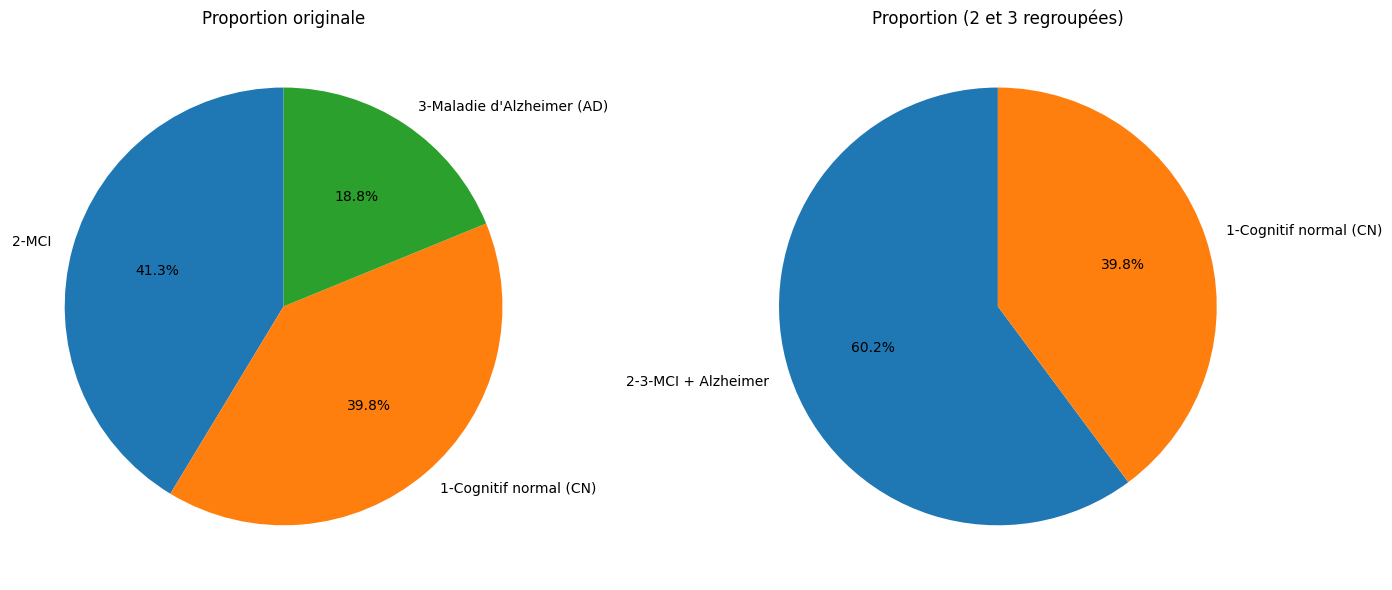

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Distribution de la variable cible DIAGNOSIS", fontsize=15, fontweight='bold')

# Camembert 1 : 3 classes originales
df['DIAGNOSIS'].map(diagnosis_labels).value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90, ax=axes[0]
)
axes[0].set_title("Répartition originale (3 classes)")
axes[0].set_ylabel('')

# Camembert 2 : on regroupe MCI et AD en une seule classe "À risque"
diag_binaire = df['DIAGNOSIS'].replace({1: 'Cognitif normal (CN)', 2: 'MCI + Alzheimer', 3: 'MCI + Alzheimer'})
diag_binaire.value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90, ax=axes[1]
)
axes[1].set_title("Répartition binaire (MCI + AD regroupés)")
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 6. Valeurs manquantes
Identification des variables nécessitant un traitement (imputation ou suppression).
ADNI utilise des **codes sentinelles numériques** (`-4`, `-1`, `9999`) en plus des `NaN` standards.

In [20]:
# Taux de NaN par colonne
taux_nan = df.isna().sum() / len(df)
taux_nan = taux_nan.sort_values(ascending=False)
taux_nan

PTOPI                   0.999875
PTORIENTOT              0.999687
PTLANGWR6               0.999562
PTLANGSP6               0.999562
PTLANGUN6               0.999562
PTLANGRD6               0.999562
PTLANGRD5               0.998624
PTLANGWR5               0.998624
PTLANGUN5               0.998624
PTLANGPR6               0.998624
PTLANGSP5               0.998624
PTLANGPR5               0.997310
PTLANGRD4               0.997310
PTLANGUN4               0.997310
PTLANGWR4               0.997310
PTLANGSP4               0.997310
PTADBEG                 0.997060
MMLTR7                  0.995747
NDREASON                0.995621
PTASIAN                 0.995309
MH14AALCH               0.994933
PTLANGWR3               0.994871
PTLANGRD3               0.994871
PTLANGPR4               0.994808
PTLANGSP3               0.994808
PTLANGUN3               0.994808
ST8SV                   0.994245
MMLTR6                  0.994120
PTETHCATH               0.991556
PTENGSPKAGE             0.990617
PTIMMAGE  

In [ ]:
# On crée un masque pour repérer toutes les valeurs manquantes (NaN ou codes ADNI)
masque = (df.isna()) | (df == -1) | (df == -4) | (df == 9999)
taux_manquant = masque.sum() / len(df)
taux_manquant.sort_values(ascending=False)

PTADBEG                 1.000000
PTOPI                   0.999875
DXPATYP                 0.999875
DXPCOG                  0.999750
PTORIENTOT              0.999687
DXPDES                  0.999625
PTLANGSP6               0.999562
PTLANGUN6               0.999562
PTLANGRD6               0.999562
PTLANGWR6               0.999562
DXOTHDEM                0.999500
MH15ADRUG               0.998937
MH15BDRUG               0.998937
PTLANGUN5               0.998624
PTLANGWR5               0.998624
PTLANGSP5               0.998624
PTLANGPR6               0.998624
PTLANGRD5               0.998624
PTLANGWR4               0.997310
PTLANGSP4               0.997310
PTLANGPR5               0.997310
PTLANGRD4               0.997310
PTLANGUN4               0.997310
DXODES                  0.996310
MMLTR7                  0.995747
NDREASON                0.995621
PTASIAN                 0.995309
MH14BALCH               0.994933
MH14AALCH               0.994933
MH14CALCH               0.994933
PTLANGRD3 

### Quantification des codes manquants ADNI
ADNI utilise des codes sentinelles numériques pour indiquer des données manquantes. Il est essentiel de les identifier et de les convertir en `NaN` avant tout traitement.

In [ ]:
adni_missing_codes = [-4, -1]
for code in adni_missing_codes:
    count = (df == code).sum().sum()
    pct = round(count / df.size * 100, 2)
    if count > 0:
        print("Code", code, ":", count, "occurrences →", pct, "% des données")

In [25]:
# % de NaN par colonne
missing_ratio = df.isna().mean() * 100
missing_ratio = missing_ratio.sort_values(ascending=False)

# Colonnes avec >= 70% de NaN
cols_high_nan = missing_ratio[missing_ratio >= 70].index.tolist()

print("Colonnes à fort taux de NaN :", cols_high_nan)
print("Nombre de colonnes à fort taux de NaN :", len(cols_high_nan))
# Résultat attendu : ~173 colonnes dépassent 70% de valeurs manquantes
# Profil de ces colonnes :
#   - PTLANG* : données linguistiques (langue parlée, lue, écrite) — rarement collectées
#   - FATH* / MOTH* : antécédents familiaux — non systématiquement renseignés
#   - HIPPOQC, OVERALLQC : contrôle qualité IRM — absent si pas d'IRM réalisée
#   - MH* (historique médical) : renseigné uniquement à certaines visites
# → Ces colonnes seront exclues du preprocessing (trop peu d'information exploitable)


Colonnes à fort taux de NaN : ['PTOPI', 'PTORIENTOT', 'PTLANGWR6', 'PTLANGSP6', 'PTLANGUN6', 'PTLANGRD6', 'PTLANGRD5', 'PTLANGWR5', 'PTLANGUN5', 'PTLANGPR6', 'PTLANGSP5', 'PTLANGPR5', 'PTLANGRD4', 'PTLANGUN4', 'PTLANGWR4', 'PTLANGSP4', 'PTADBEG', 'MMLTR7', 'NDREASON', 'PTASIAN', 'MH14AALCH', 'PTLANGWR3', 'PTLANGRD3', 'PTLANGPR4', 'PTLANGSP3', 'PTLANGUN3', 'ST8SV', 'MMLTR6', 'PTETHCATH', 'PTENGSPKAGE', 'PTIMMAGE', 'PTBIRPL', 'PTIMMWHY', 'PTLANGWR2', 'PTLANGSP2', 'PTLANGUN2', 'PTLANGRD2', 'PTLANGPR3', 'IHCOMM', 'PTLANGSP1', 'PTLANGUN1', 'PTLANGWR1', 'PTLANGRD1', 'PTLANGTTL', 'PTLANGPR2', 'PTLANGPR1', 'FATHSXAGE', 'FATHAD', 'VSHGTSC', 'ST68SV', 'MOTHSXAGE', 'MOTHAD', 'PTORIENT', 'OVERALLQC', 'FRONTQC', 'PARQC', 'OCCQC', 'INSULAQC', 'BGQC', 'HIPPOQC', 'CWMQC', 'VENTQC', 'TEMPQC', 'PTWORK', 'PTIDENT', 'PTENGSPK', 'PTSPTIM', 'PTNLANG', 'PTLANGWR', 'PTLANGSP', 'PTSPOTTIM', 'PTCLANG', 'PTBIRGR', 'PTBIRPR', 'PTBORN', 'MH15ADRUG', 'MH15BDRUG', 'IHCEASE', 'MH14CALCH', 'MHSOURCE', 'MH18SURG', 'MH6

## 7. Distribution des variables
Analyse des distributions des **top variables numériques** les plus corrélées avec `DIAGNOSIS` (après filtre sur les colonnes avec trop de valeurs manquantes).

> **Note** : Certains `float` seraient plutôt des variables catégorielles (`MMDATE`, `WORD1DL`, etc.) — 0 = Incorrect, 1 = Correct. Python les stocke en nombre décimal dès qu'il y a des valeurs manquantes (`NaN`).

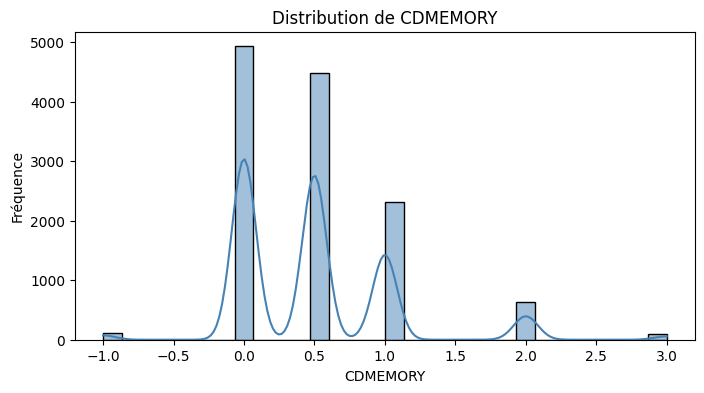

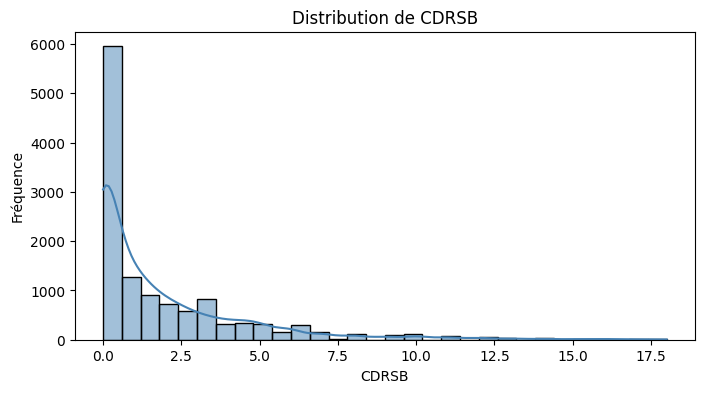

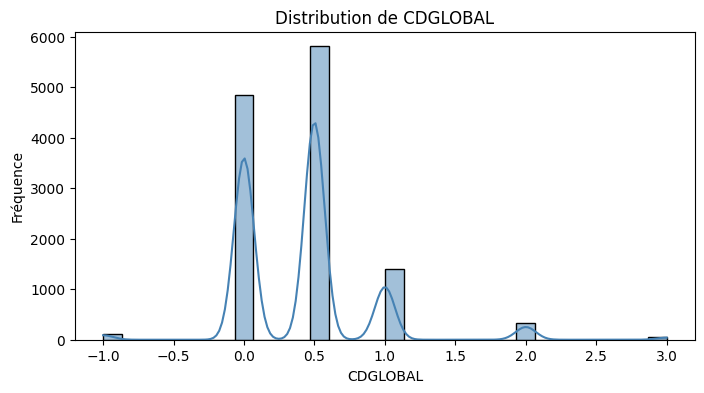

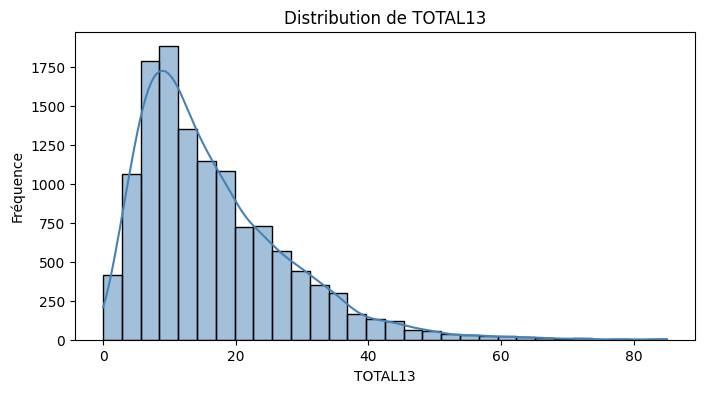

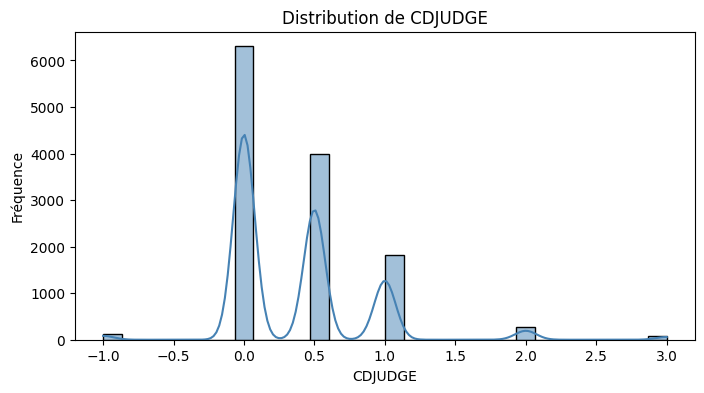

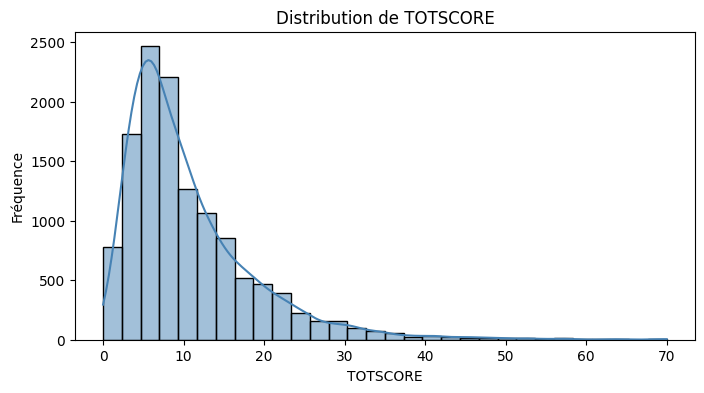

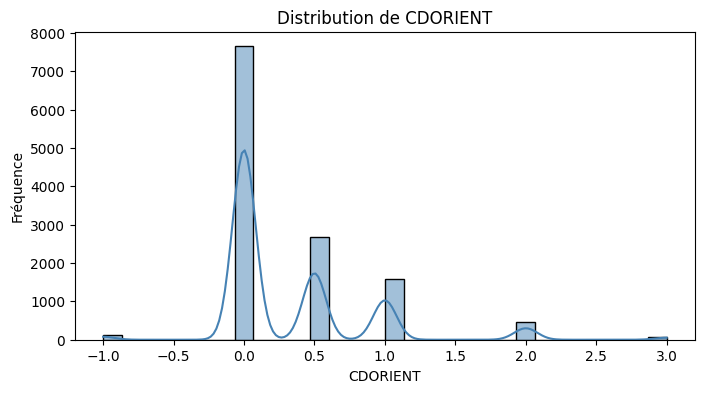

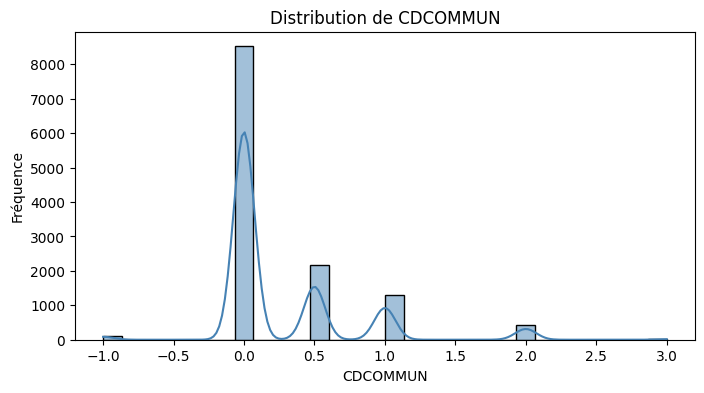

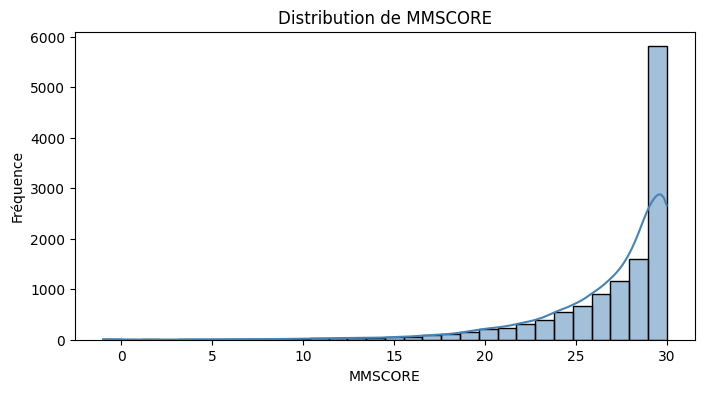

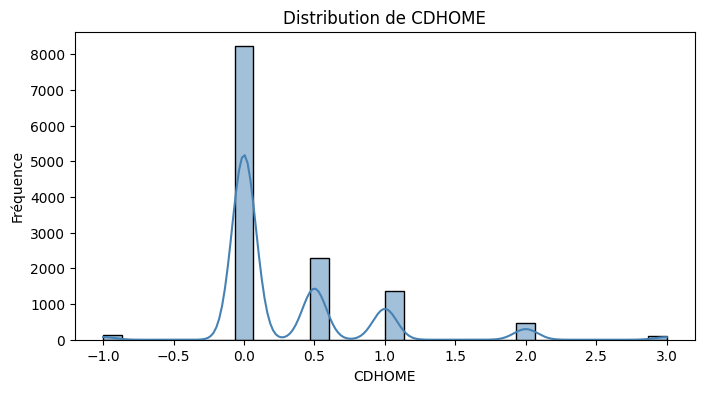

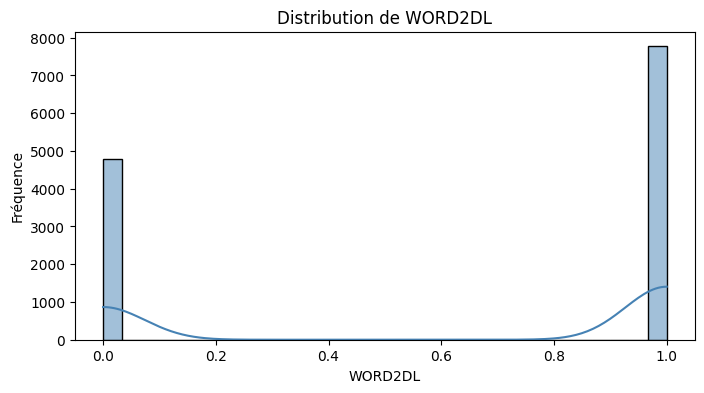

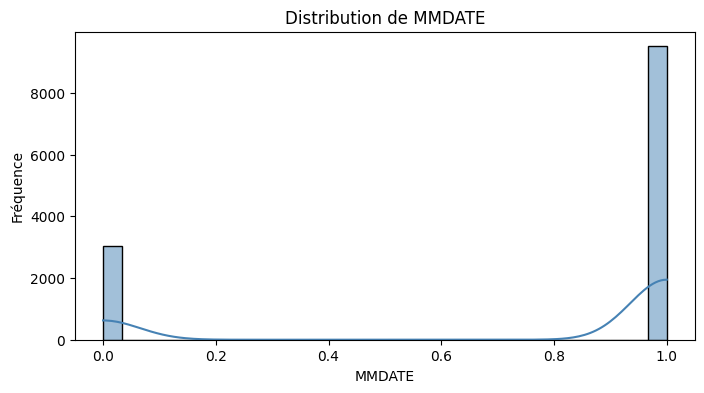

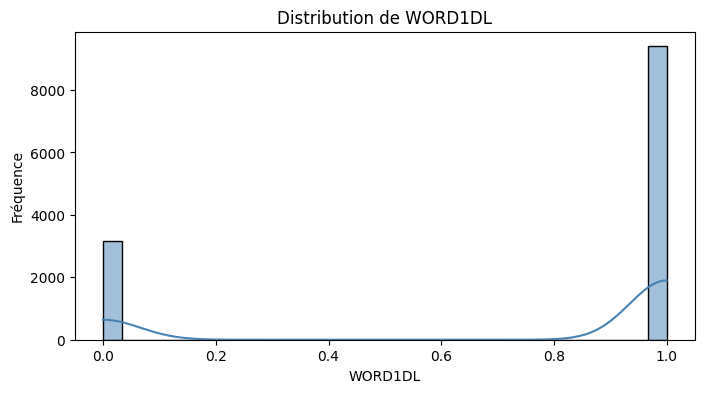

In [ ]:
# Colonnes numériques sans la cible DIAGNOSIS
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'DIAGNOSIS']

# Garder seulement les colonnes avec moins de 30% de valeurs manquantes
num_cols = [c for c in num_cols if df[c].isna().mean() < 0.3]

# Corrélation de chaque variable avec DIAGNOSIS
corr_avec_diag = df[num_cols + ['DIAGNOSIS']].corr()['DIAGNOSIS'].abs()
corr_avec_diag = corr_avec_diag.sort_values(ascending=False)
top_cols = corr_avec_diag.head(15).index.tolist()
top_cols = [c for c in top_cols if c != 'DIAGNOSIS']

# Histogramme pour chaque variable du top
for col in top_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, kde=True, bins=30, color='steelblue')
    plt.title("Distribution de " + col)
    plt.xlabel(col)
    plt.ylabel("Nombre d'observations")
    plt.tight_layout()
    plt.show()

## 8. Boxplots — Détection des outliers
Distribution des top variables par classe de diagnostic. Permet de visualiser les valeurs extrêmes et la séparation entre CN / MCI / AD.

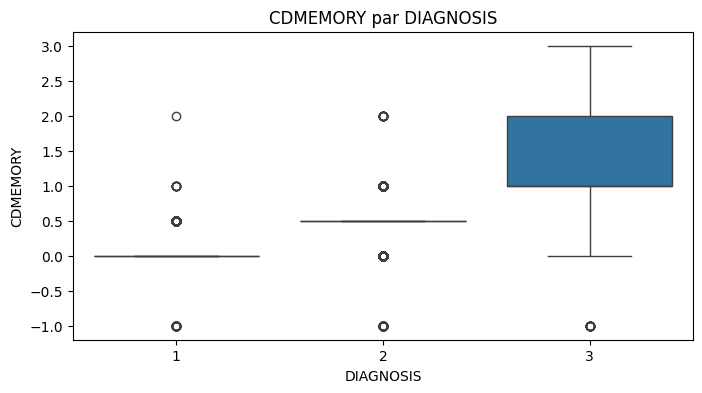

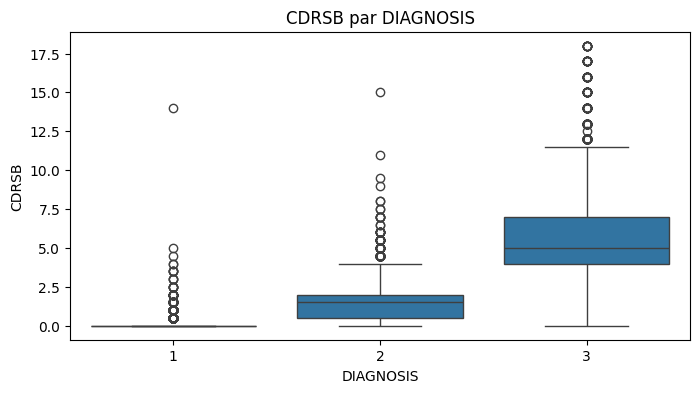

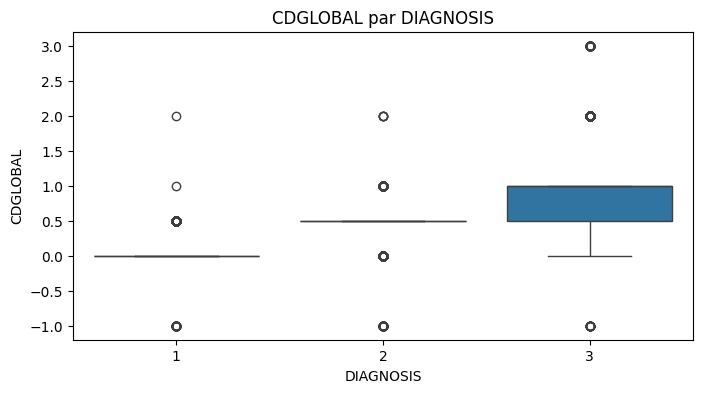

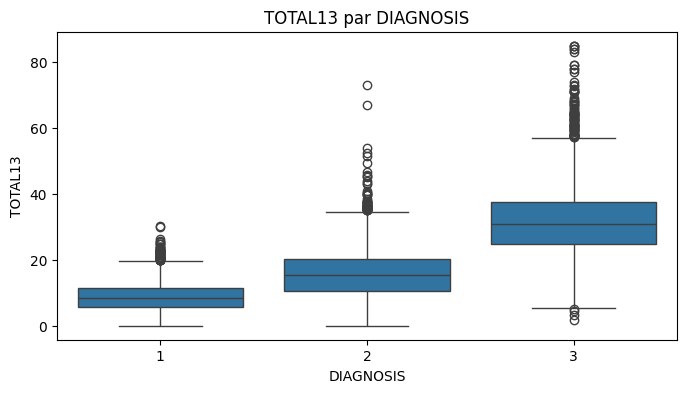

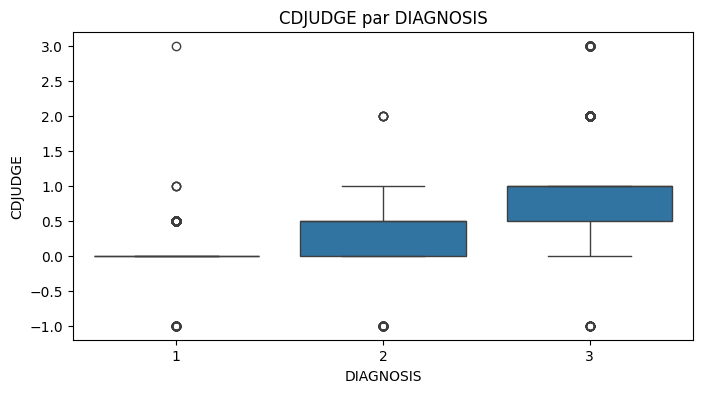

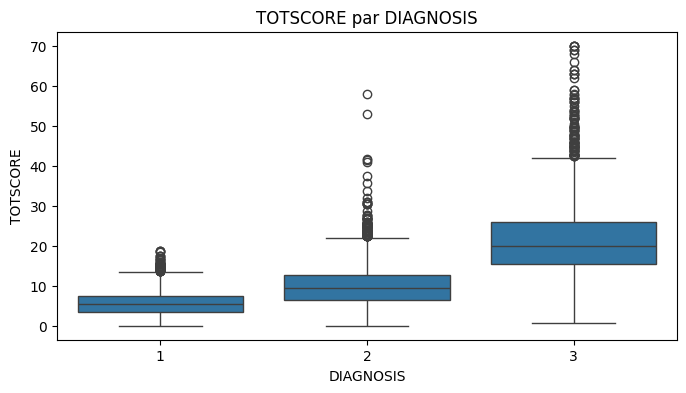

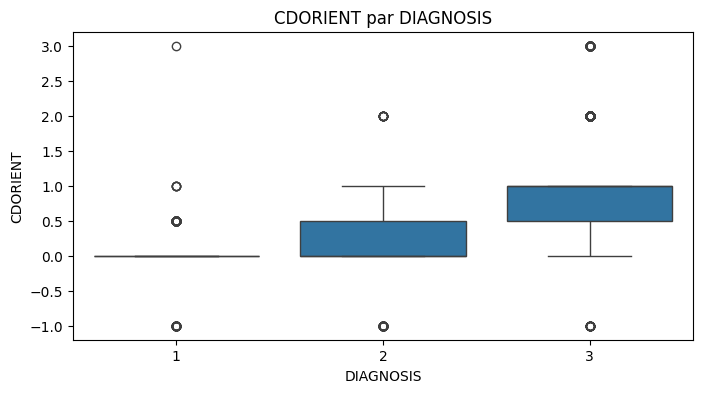

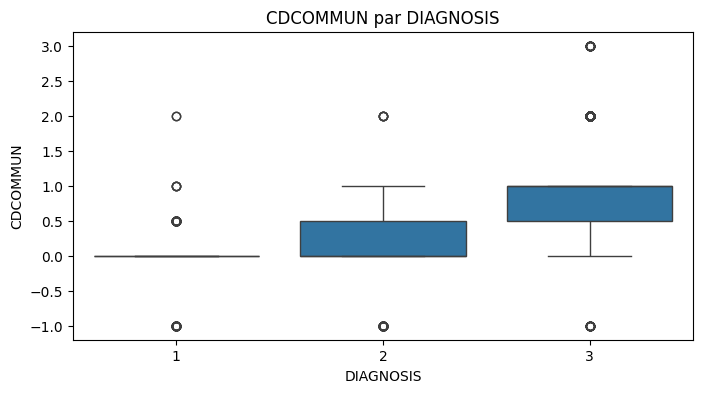

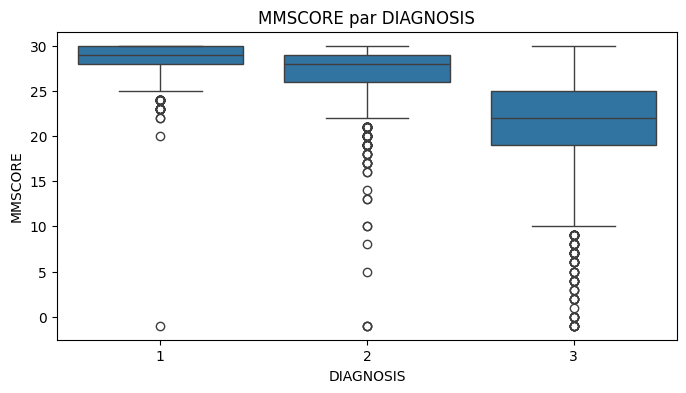

In [27]:
# Mêmes filtres que pour les histogrammes
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'DIAGNOSIS']
num_cols = [c for c in num_cols if df[c].isna().mean() < 0.3]

corr_avec_diag = df[num_cols + ['DIAGNOSIS']].corr()['DIAGNOSIS'].abs()
corr_avec_diag = corr_avec_diag.sort_values(ascending=False)
top_cols = corr_avec_diag.head(15).index.tolist()
top_cols = [c for c in top_cols if c != 'DIAGNOSIS']

# Ajouter une colonne lisible pour le diagnostic
df['Diagnostic'] = df['DIAGNOSIS'].replace({1: 'CN', 2: 'MCI', 3: 'AD'})

# Boxplot pour chaque variable
for col in top_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='Diagnostic', y=col, data=df, order=['CN', 'MCI', 'AD'], palette='Set2')
    plt.title(col + " selon le diagnostic")
    plt.tight_layout()
    plt.show()

## 9. Corrélations
Identification des variables numériques les plus liées à `DIAGNOSIS` et détection des paires redondantes (corrélation inter-variable > 0.8).

In [57]:
# Variables numériques sans la cible, avec peu de valeurs manquantes
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'DIAGNOSIS']
num_cols = [c for c in num_cols if df[c].isna().mean() < 0.3]

# Corrélation absolue avec DIAGNOSIS
corr = df[num_cols + ['DIAGNOSIS']].corr()['DIAGNOSIS'].abs()
corr = corr.drop('DIAGNOSIS')
top20 = corr.sort_values(ascending=False).head(20)

print("Top 20 corrélations avec DIAGNOSIS :")
print(top20)

Top 20 corrélations (après filtres) :
CDMEMORY    0.778667
CDRSB       0.752892
CDGLOBAL    0.750700
TOTAL13     0.723560
CDJUDGE     0.682610
TOTSCORE    0.682264
CDORIENT    0.674632
CDCOMMUN    0.652732
MMSCORE     0.649152
CDHOME      0.637482
WORD2DL     0.527282
MMDATE      0.525275
WORD1DL     0.517369
Name: DIAGNOSIS, dtype: float64


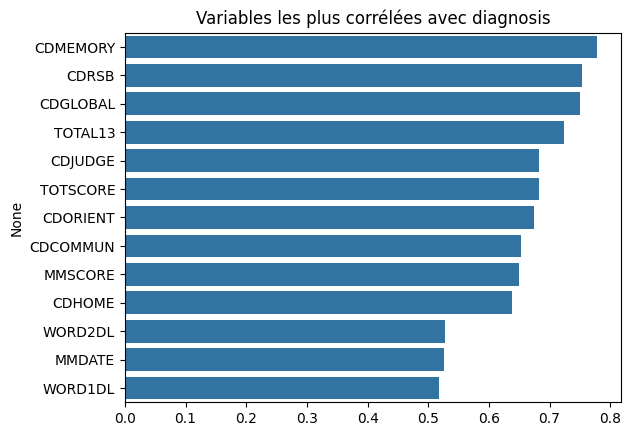

In [58]:
plt.figure(figsize=(9, 5))
plt.barh(top20.index[::-1], top20.values[::-1], color='steelblue')
plt.title("Variables les plus corrélées avec DIAGNOSIS")
plt.xlabel("Corrélation absolue avec DIAGNOSIS")
plt.axvline(0.5, color='red', linestyle='--', label='seuil 0.5')
plt.legend()
plt.tight_layout()
plt.show()

### Alerte : corrélation trompeuse de PTCOGBEG
PTCOGBEG ressort avec une corrélation élevée (-0.78) mais la variable est **quasi-vide**. Une corrélation calculée sur très peu de valeurs non-`NaN` n'est pas fiable — c'est un **artefact statistique**.

In [ ]:
if 'PTCOGBEG' in df.columns:
    n_nan = df['PTCOGBEG'].isna().sum()
    taux_nan = round(n_nan / len(df) * 100, 1)
    n_valides = df['PTCOGBEG'].notna().sum()
    print("Taux de NaN :", taux_nan, "%")
    print("Valeurs non-NaN :", n_valides, "sur", len(df))
    print(df['PTCOGBEG'].describe())
else:
    print("PTCOGBEG absente du dataset")

In [ ]:
# Corrélation entre variables numériques (sans la cible)
df_numeric = df.select_dtypes(include=[np.number]).drop(columns='DIAGNOSIS')

# Corrélation de chaque variable avec DIAGNOSIS
corr_target = df[df_numeric.columns.tolist() + ['DIAGNOSIS']].corr()['DIAGNOSIS'].abs()

# Matrice de corrélation entre variables
corr_matrix = df_numeric.corr().abs()
colonnes = corr_matrix.columns.tolist()

# Trouver les paires très corrélées entre elles (> 0.8)
print("Paires de variables très corrélées (> 0.8) :")
for i in range(len(colonnes)):
    for j in range(i + 1, len(colonnes)):
        val = corr_matrix.iloc[i, j]
        if val > 0.8:
            col_a = colonnes[i]
            col_b = colonnes[j]
            corr_a = round(corr_target.get(col_a, 0), 3)
            corr_b = round(corr_target.get(col_b, 0), 3)
            if corr_a >= corr_b:
                gardee, supprimee = col_a, col_b
            else:
                gardee, supprimee = col_b, col_a
            print(col_a, "/", col_b, " → corr =", round(val, 3), "| garder :", gardee, "| supprimer :", supprimee)

      var_A  corr_A_vs_target       var_B  corr_B_vs_target  corr_entre_elles      gardee   supprimee
  PTLANGUN6             0.028      ST97TS             0.096             1.000      ST97TS   PTLANGUN6
  PTLANGWR6             0.329      ST97TS             0.096             1.000   PTLANGWR6      ST97TS
  PTLANGRD6             0.248      ST97TS             0.096             1.000   PTLANGRD6      ST97TS
  PTLANGSP6             0.403      ST97TS             0.096             1.000   PTLANGSP6      ST97TS
  PTLANGUN6             0.028      ST97TA             0.217             1.000      ST97TA   PTLANGUN6
  PTLANGWR6             0.329      ST97TA             0.217             1.000   PTLANGWR6      ST97TA
  PTLANGRD6             0.248      ST97TA             0.217             1.000   PTLANGRD6      ST97TA
  PTLANGSP6             0.403      ST97TA             0.217             1.000   PTLANGSP6      ST97TA
  PTLANGUN6             0.028      ST97SA             0.014             1.000   PT

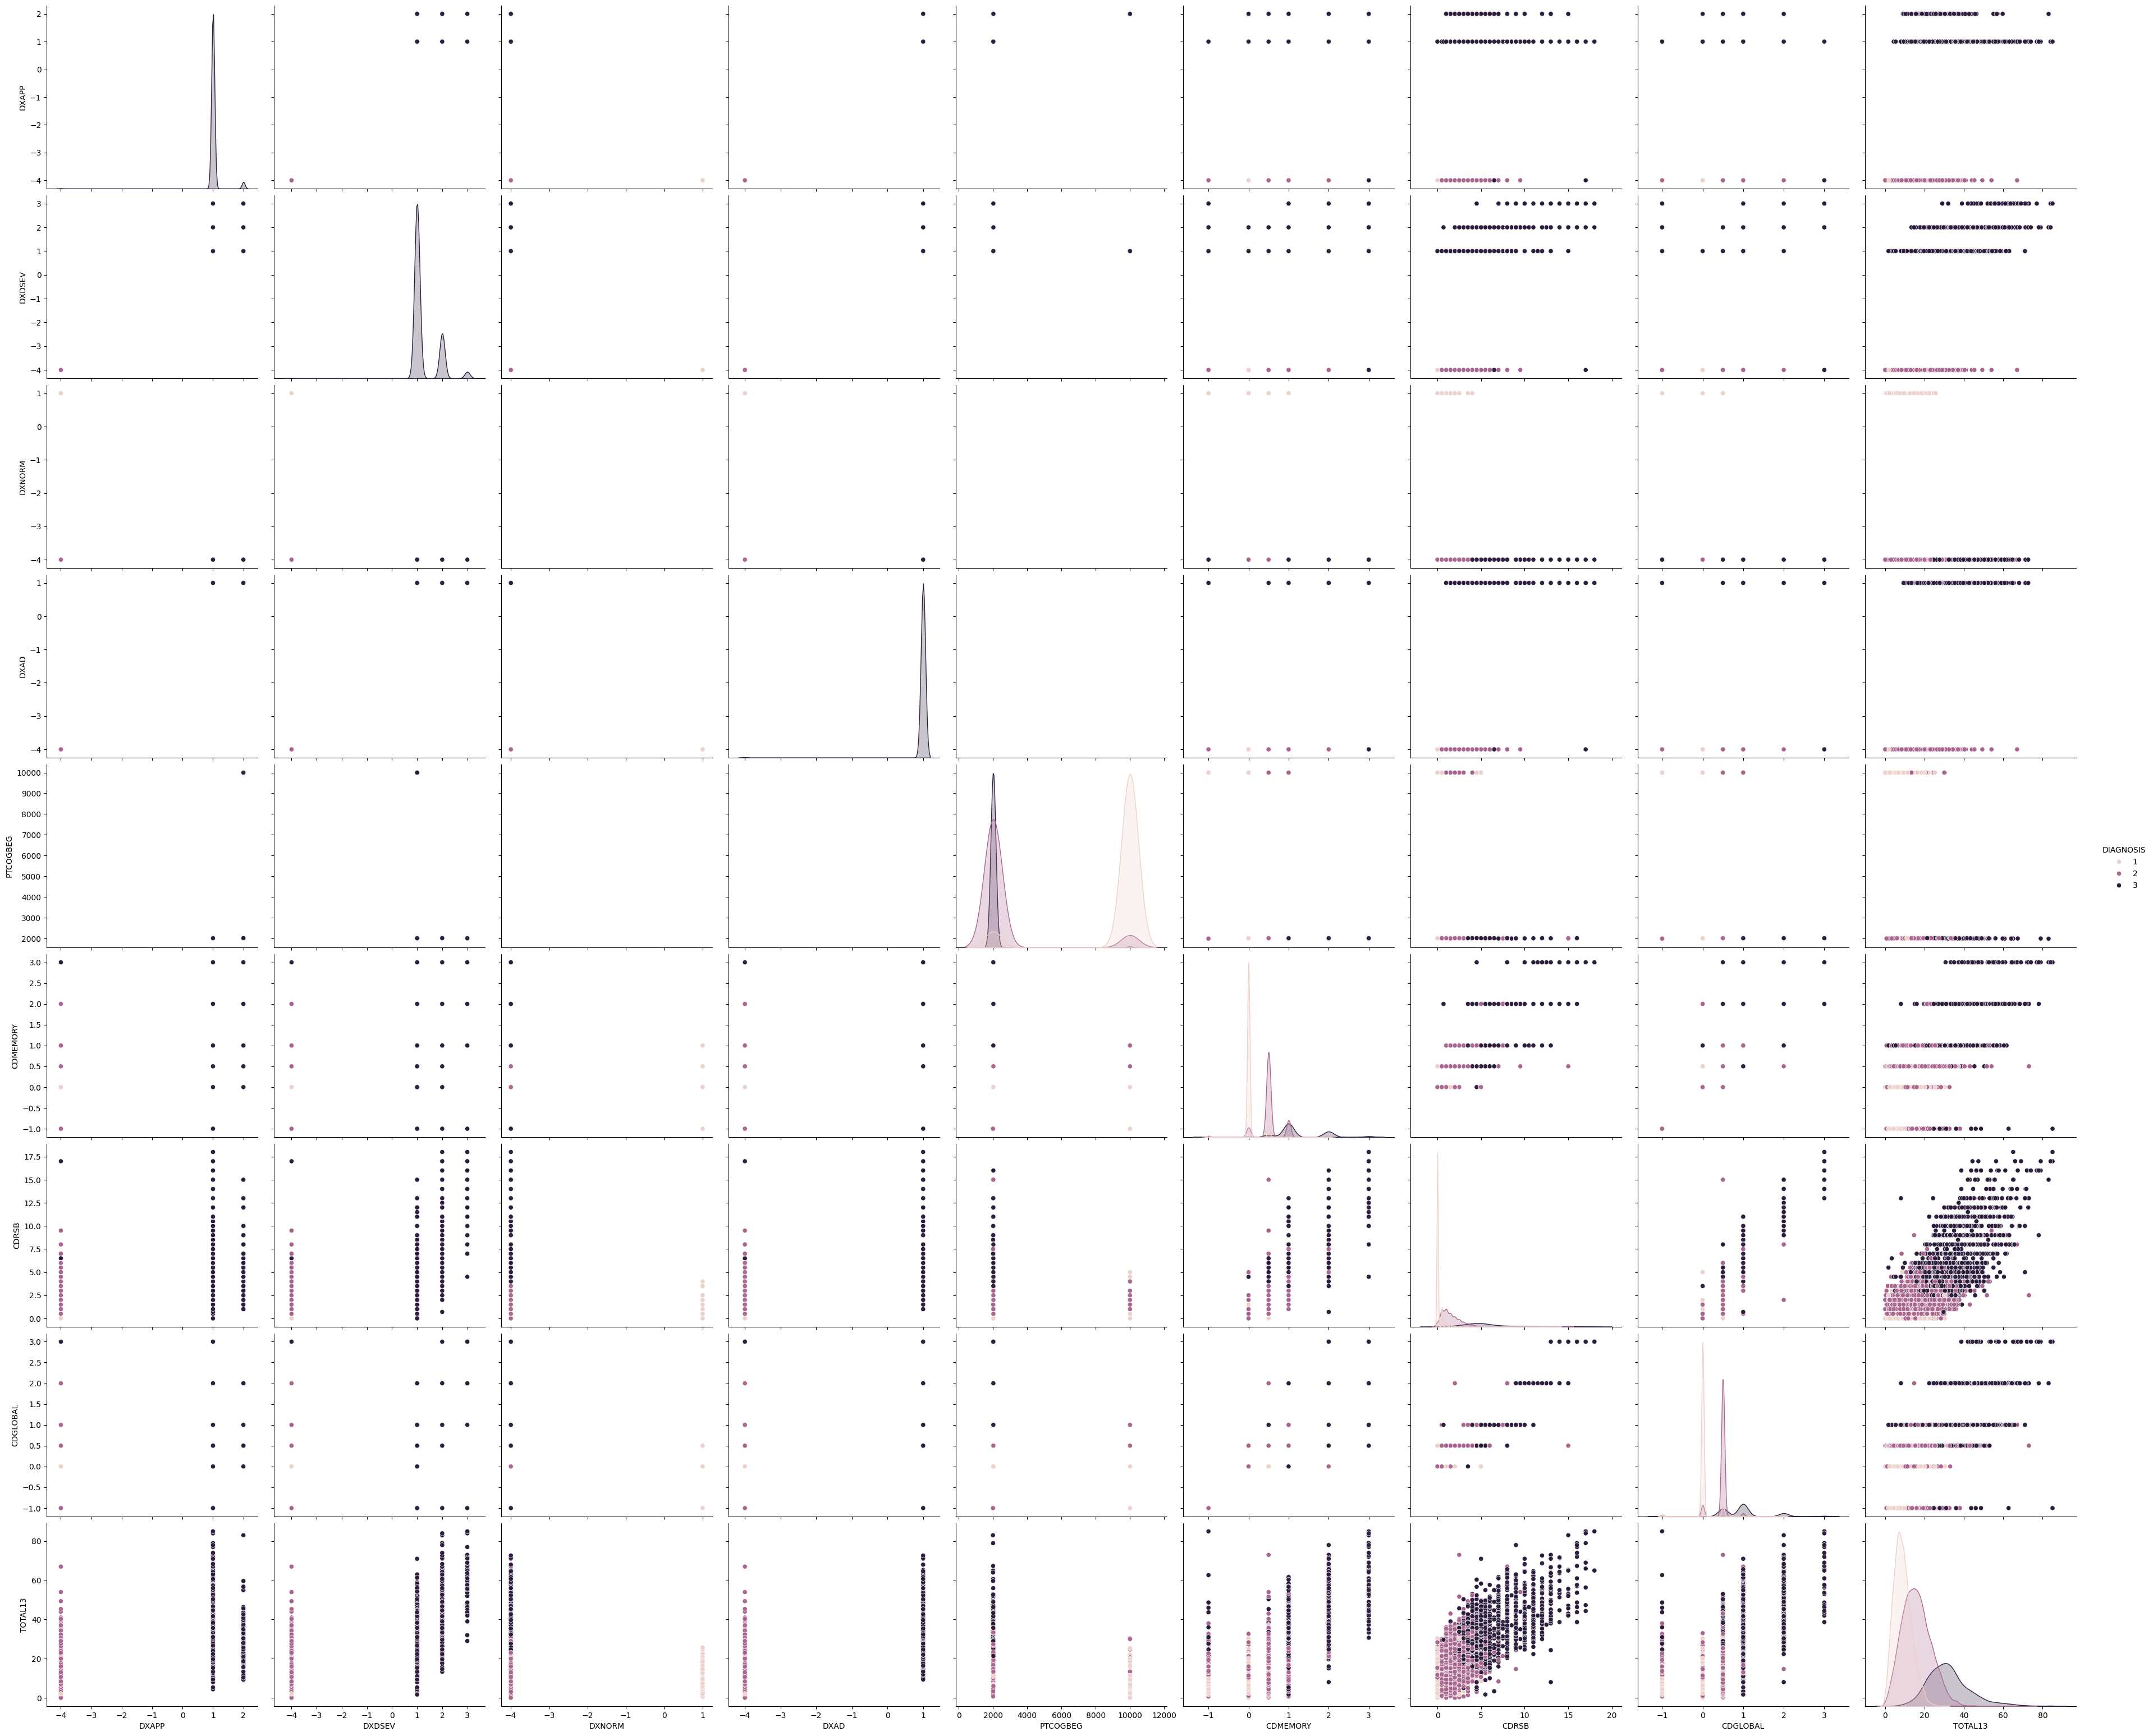

In [69]:
# Corrélation de chaque variable avec DIAGNOSIS
corr = df.corr(numeric_only=True)['DIAGNOSIS'].abs()
corr = corr.sort_values(ascending=False)

# Top 10 colonnes les plus corrélées
top_cols = corr.head(10).index.tolist()

# Pairplot : chaque point = une observation, colorée par diagnostic
sns.pairplot(df[top_cols], hue='DIAGNOSIS', height=3.5)
plt.show()

## 10. Colonnes constantes et quasi-constantes
Des colonnes sans variance n'apportent aucune information au modèle et doivent être supprimées.

In [ ]:
# Colonnes constantes (une seule valeur unique dans toute la colonne)
# Résultat attendu : ['PTADBEG', 'PTOPI']
#   PTADBEG : date de début de l'Alzheimer — jamais renseignée (NaN pour tous les patients)
#   PTOPI   : variable de suivi ophtalmologique — jamais collectée dans ce dataset
# Ces colonnes ont une variance nulle → aucune information pour le modèle → à supprimer
[col for col in df.columns if df[col].nunique() <= 1]


['PTADBEG', 'PTOPI']

In [ ]:
threshold = 0.99
quasi_const_cols = []

for col in df.columns:
    top_value_pct = df[col].value_counts(normalize=True).iloc[0]
    if top_value_pct >= threshold:
        quasi_const_cols.append(col)

print(quasi_const_cols)

['LANGUAGE_CODE',
 'DXPDES',
 'DXPCOG',
 'DXPATYP',
 'DXOTHDEM',
 'MHSOURCE',
 'SOURCE',
 'MMWATCH',
 'MMPENCIL',
 'PXABNORM',
 'PTSOURCE',
 'PTADBEG',
 'PTOPI']

In [ ]:
for col in df:
    if df[col].nunique() == 0 or col == 'MMYEAR':
        print(col, ":", df[col].unique())

In [60]:
print("Nombre de valeurs différentes par colonne :\n",df.nunique().sort_values(ascending=False))
# Lecture du résultat :
#   En tête (valeurs uniques élevées) : RID, VISDATE, PTID → identifiants purs, à exclure
#   Milieu (3 à ~200 valeurs) : scores et mesures continues → variables analytiques
#   En bas (1-2 valeurs uniques) : variables binaires ou constantes → à vérifier
# Règle pratique :
#   nunique == 1 → constante, à supprimer
#   nunique == 2 → variable binaire (voir cellule suivante)
#   nunique > seuil (ex: 50%) du nombre de lignes → probablement un identifiant


Nombre de valeurs différentes par colonne :
 Id                      14254
IMAGEUID                 8931
ST10CV                   8918
ST154SV                  8915
ST149SV                  8915
ST148SV                  8915
ST147SV                  8915
ST155SV                  8797
ST37SV                   8783
ST96SV                   8770
ST28SA                   8761
ST87sa                   8759
ST17SV                   8720
ST76SV                   8717
ST151SV                  8716
ST150SV                  8709
ST152SV                  8689
ST1SV                    8456
ST128SV                  8454
ST18SV                   8355
ST77SV                   8351
ST61SV                   7578
ST120SV                  7545
ST127SV                  7408
ST112SV                  7300
ST53SV                   7287
ST88SV                   7230
ST30SV                   7201
ST9SV                    7195
ST153SV                  7143
ST29SV                   7139
ST75SV                   

In [ ]:
print("Colonnes avec 2 valeur :\n",df.nunique()[df.nunique() == 2])
# Ces colonnes sont des variables binaires : réponses Oui/Non, Pass/Fail, Correct/Incorrect
# Exemples :
#   DXNORM (1/0) : diagnostic normal ?
#   HIPPOQC, TEMPQC... (Pass/Fail) : contrôle qualité de l'IRM par région cérébrale
#   WORD1DL, WORD2DL (1/0) : mot rappelé correctement lors du test de mémoire différée ?
#   MH4CARD, MH9ENDO... (1/0) : antécédent médical présent ?
#   FIELD_STRENGTH (1.5T/3T) : intensité du champ magnétique de l'IRM
# Ces variables sont déjà en format 0/1 → peu de transformation nécessaire
# Attention : Python les stocke en nombre décimal à cause des valeurs manquantes
#             → à convertir dans leur bon format après le remplissage des valeurs manquantes


## 11. Analyse des variables catégorielles
Identification des variables objet exploitables et de leur lien avec `DIAGNOSIS`.
Vérification de la qualité IRM (`HIPPOQC`, `OVERALLQC`) et détection du data leakage.

In [ ]:
obj_cols = df.select_dtypes(include=['object']).columns

for col in obj_cols:
    if df[col].nunique() < 3:
        print(col, ":", df[col].unique())

DD_CRF_VERSION_LABEL********** <StringArray>
[nan, 'list1', 'v1']
Length: 3, dtype: str
LANGUAGE_CODE***************** <StringArray>
[nan, 'e', 's']
Length: 3, dtype: str
DONE************************** <StringArray>
[nan, '1', '0']
Length: 3, dtype: str
SOURCE************************ <StringArray>
[nan, '1', '2']
Length: 3, dtype: str
FIELD_STRENGTH**************** <StringArray>
[nan, '1.5T', '3T']
Length: 3, dtype: str
STATUS************************ <StringArray>
[nan, 'partial', 'complete']
Length: 3, dtype: str
FSVER************************* <StringArray>
[nan, '7.2.0', '7.4.1']
Length: 3, dtype: str
TEMPQC************************ <StringArray>
[nan, 'Fail', 'Pass']
Length: 3, dtype: str
FRONTQC*********************** <StringArray>
[nan, 'Fail', 'Pass']
Length: 3, dtype: str
PARQC************************* <StringArray>
[nan, 'Fail', 'Pass']
Length: 3, dtype: str
INSULAQC********************** <StringArray>
[nan, 'Fail', 'Pass']
Length: 3, dtype: str
OCCQC************************* <S

C:\Users\Magalie\AppData\Local\Temp\ipykernel_19064\1831255985.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include=['object']).columns


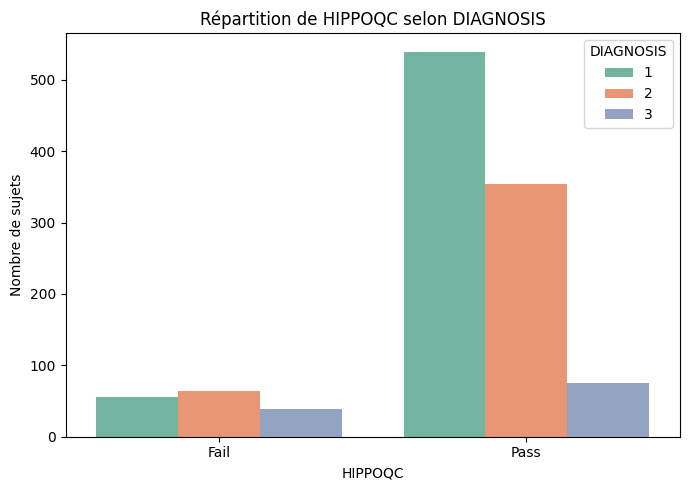

In [16]:

plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x='HIPPOQC',
    hue='DIAGNOSIS',
    palette='Set2'
)

plt.title("Répartition de HIPPOQC selon DIAGNOSIS")
plt.xlabel("HIPPOQC")
plt.ylabel("Nombre de sujets")
plt.tight_layout()
plt.show()


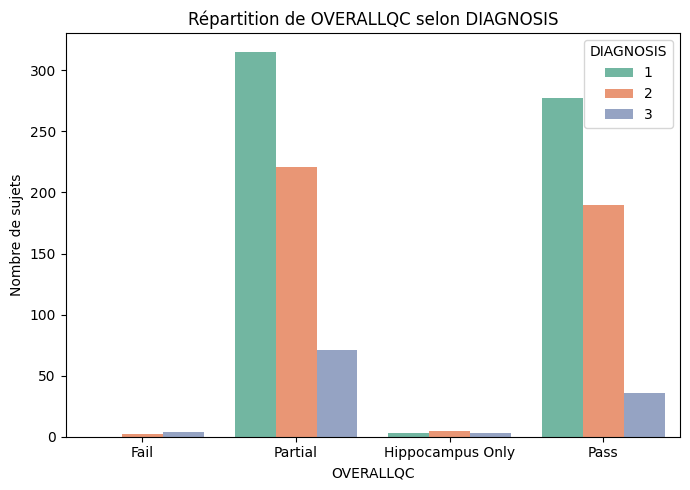

In [15]:
plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x='OVERALLQC',
    hue='DIAGNOSIS',
    palette='Set2'
)

plt.title("Répartition de OVERALLQC selon DIAGNOSIS")
plt.xlabel("OVERALLQC")
plt.ylabel("Nombre de sujets")
plt.tight_layout()
plt.show()

### Alerte data leakage — Variables catégorielles liées au diagnostic
Certaines variables catégorielles présentent une association très forte avec `DIAGNOSIS` (mesurée par le **V de Cramér**). Cela indique un risque de **fuite de données** : ces variables sont probablement des dérivés ou descriptions du diagnostic.

| Variable | V de Cramér | Interprétation |
|---|---|---|
| `DXMDES` | ~0.71 | Description textuelle du diagnostic — **exclure** |
| `NDREASON` | ~0.46 | Raison de la visite liée au diagnostic — **exclure** |
| `PHASE` | ~0.18 | Association faible, peut être conservée |


In [ ]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    tableau = pd.crosstab(x, y)
    chi2, p, dof, expected = chi2_contingency(tableau)
    n = tableau.sum().sum()
    v = np.sqrt(chi2 / (n * (min(tableau.shape) - 1)))
    return v

colonnes_a_verifier = ['DXMDES', 'NDREASON', 'PHASE']
print("Association avec DIAGNOSIS (V de Cramér) :")
for col in colonnes_a_verifier:
    if col in df.columns:
        temp = df[[col, 'DIAGNOSIS']].dropna()
        if len(temp) > 0:
            v = cramers_v(temp[col], temp['DIAGNOSIS'])
            if v > 0.5:
                print(" ", col, ": V =", round(v, 3), "→ risque de data leakage !")
            else:
                print(" ", col, ": V =", round(v, 3))

<Axes: >

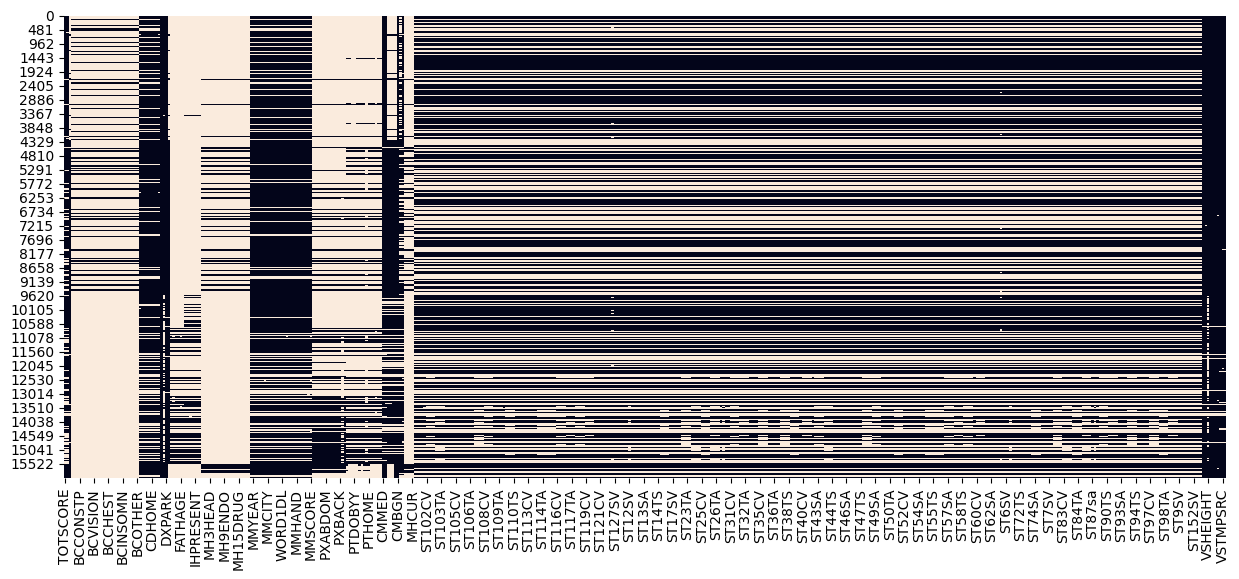

In [ ]:
plt.figure(figsize=(16, 6))
sns.heatmap(df.isna(), cbar=False, yticklabels=False)
plt.title("Carte des valeurs manquantes (blanc = manquant)")
plt.xlabel("Colonnes")
plt.ylabel("Observations")
plt.tight_layout()
plt.show()

## 12. Analyse longitudinale
Le dataset contient **plusieurs visites par patient** — les observations ne sont pas indépendantes. Cette structure temporelle doit être prise en compte lors de la modélisation.

In [29]:
# Nombre de patients uniques dans le dataset
print("Nombre de patients :", df['RID'].nunique())
# Résultat attendu : 3 777 patients uniques
# Le dataset contient donc 15 987 lignes pour 3 777 patients
# → en moyenne ~4.2 visites par patient (structure longitudinale confirmée)
# Les lignes ne sont PAS indépendantes : un même patient apparaît plusieurs fois
# → un split train/test naïf pourrait mettre des visites du même patient
#   des deux côtés → fuite de données temporelle à éviter


Nombre de patients : 3777


In [31]:
visites_par_patient = df.groupby('RID')['VISDATE'].count()
moyenne_visites = visites_par_patient.mean()
print("Nombre moyen de visites par patient :", round(moyenne_visites, 2))

Nombre moyen de visites par patient : 4.168387609213662


In [52]:
visits_per_patient = df.groupby('RID')['VISDATE'].count()
multi_visit_patients = visits_per_patient[visits_per_patient > 1].index[:20].tolist()

df_tracking = df[df['RID'].isin(multi_visit_patients)].copy()
df_tracking = df_tracking.sort_values(['RID', 'VISDATE'])

df_tracking['MMSCORE_clean'] = df_tracking['MMSCORE'].replace([-4, -1], np.nan)

fig = go.Figure()

for patient in multi_visit_patients:
    data_patient = df_tracking[df_tracking['RID'] == patient]
    fig.add_trace(go.Scatter(
        x=data_patient['VISDATE'],
        y=data_patient['MMSCORE_clean'],
        mode='lines+markers',
        name='Patient ' + str(patient),
        showlegend=False
    ))

fig.update_layout(
    title='Évolution du score MMSE au fil des visites (20 patients)',
    xaxis_title='Date de visite',
    yaxis_title='Score MMSE',
    height=500
)

fig.show()

## Recommandations pour le Preprocessing et la Modélisation

---

### 1. Gestion des valeurs manquantes
- Convertir les codes ADNI non standard (`-4`, `-1`, `9999`) en `NaN` avant tout traitement
- Envisager l'exclusion des variables présentant plus de **50 % de valeurs manquantes**, sauf justification clinique
- **Remplissage des manquants** : variables numériques → valeur médiane (robuste aux valeurs extrêmes), variables catégorielles → valeur la plus fréquente

### 2. Variable cible
- Cible primaire : `DIAGNOSIS` (1 = Normal, 2 = MCI, 3 = AD)
- Pour la détection précoce, regroupement MCI et AD :
  - **0** = Sain (≈ 40 %)
  - **1** = À risque Alzheimer (≈ 60 %)
- Déséquilibre léger → prévoir une **stratification** lors du découpage train/test

### 3. Variables catégorielles
- Certaines colonnes stockées en nombre décimal sont en réalité des variables catégorielles (`MMDATE`, `WORD1DL`, etc.) : 0 = Incorrect, 1 = Correct
- Python les stocke en nombre décimal en présence de valeurs manquantes — à convertir dans leur bon format après le remplissage

### 4. Variables prédictives principales
Supprimer les colonnes techniques : `RID`, `VISCODE`, `VISCODE2`, `PTID`, `VISDATE`, `SITEID`, `USERDATE`, `EXAMDATE`, `PHASE`, `RUNDATE`

Exclure toutes les variables `DX*` (`DXAPP`, `DXDSEV`, `DXAD`, `DXMDES`…) — **risque de fuite de données vers la cible**

Features retenues par domaine :

| Domaine | Variables |
|---|---|
| **Cognitif** | CDRSB, CDGLOBAL, CDMEMORY, CDJUDGE, CDCOMMUN, CDHOME, TOTSCORE, TOTAL13, WORD2DL, WORD1DL, MMSCORE, CDCARE |
| **Physiologique** | VSWEIGHT, VSHEIGHT, VSBPSYS, VSBPDIA, VSPULSE, VSWTUNIT, VSHTUNIT |
| **Imagerie** | ST101SV, ST112SV, ST120SV, ST125SV |
| **Démographique** | PTGENDER, PTMARRY, PTHAND, PTEDUCAT |
| **Médical** | MH4CARD, MH9ENDO, MH14ALCH, MH16SMOK, MH2NEURL, MHPSYCH, MH11HEMA, MH6HEPAT |

### 5. Détection des anomalies
- Décision selon la plausibilité clinique : on plafonne la valeur si elle est extrême mais exploitable, on la supprime si elle est cliniquement impossible

### 6. Feature Engineering
- **IMC** : poids / taille² (en m)
- Harmonisation des unités (cm, kg) pour les données issues de différentes sources ADNI
- **Ratio tension** : pression systolique / pression diastolique
- **Pression pulsée** : pression systolique − pression diastolique

### 7. Alerte qualité ADNI
Tous les patients avec `PTID` du type `381_S_10###` doivent être **supprimés** — données de mauvaise qualité signalées sur le site ADNI.
